# Validasi katalog WHO lengkap: XGBoost baseline vs XGBoost hybrid

Notebook ini dibuat untuk menjawab revisi reviewer pada bagian validasi biologis: validasi tidak lagi hanya memakai 8 kasus literatur, tetapi diperluas ke katalog WHO mutations edisi kedua.

Prinsip validasi:

- Sumber katalog: PDF resmi WHO yang diberikan dan file `mutations.csv` sebagai bentuk machine-readable dari katalog tersebut.
- Baris WHO dengan label biner jelas dipakai sebagai ground truth: `Assoc w R`, `Assoc w R - Interim`, `Not assoc w R`, dan `Not assoc w R - Interim`.
- Baris `Uncertain significance` dan nilai kosong tetap dihitung sebagai cakupan katalog, tetapi tidak dipakai untuk akurasi/F1/AUC karena bukan label biner yang valid.
- Metrik utama untuk pemilihan model: macro-F1, F1 kelas resisten, recall kelas resisten, AUROC, dan PR-AUC. Akurasi tetap dilaporkan, tetapi tidak dijadikan satu-satunya dasar karena kelas resisten lebih sedikit.
- Catatan penting: artefak `xgb_only_baseline.joblib` yang diberikan membutuhkan 448 fitur, sama seperti `xgb_hybrid_gnn_sem.joblib`. Jadi notebook ini membandingkan dua artefak model yang diberikan dengan representasi 448-dimensi yang sama. Jika ingin baseline tabular murni 3 fitur, model dan encoder tabular perlu disimpan terpisah dari notebook training lama.


In [1]:
from pathlib import Path
import hashlib
import json
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
# Path configuration. This works when the notebook is run from either:
# 1) C:\Semester 7\Project Tugas Akhir
# 2) C:\Semester 7\Project Tugas Akhir\Tugas Akhir
cwd = Path.cwd()
if (cwd / "mutations.csv").exists():
    DATA_DIR = cwd
elif (cwd / "Tugas Akhir" / "mutations.csv").exists():
    DATA_DIR = cwd / "Tugas Akhir"
else:
    raise FileNotFoundError("Tidak menemukan mutations.csv. Jalankan notebook dari folder proyek atau folder Tugas Akhir.")

WHO_PDF_PATH = Path(r"C:\Semester 7\Jurnal Tugas Akhir\jurnal baru\katalog who.pdf")
MUTATIONS_CSV = DATA_DIR / "mutations.csv"

MODEL_BASELINE_PATH = DATA_DIR / "xgb_only_baseline.joblib"
MODEL_HYBRID_PATH = DATA_DIR / "xgb_hybrid_gnn_sem.joblib"
GRAPH_INDEX_PATH = DATA_DIR / "graph_index.joblib"
NODE_EMBEDDINGS_PATH = DATA_DIR / "node_embeddings.npy"

OUTPUT_DIR = DATA_DIR / "who_validation_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SEMANTIC_MODEL_NAME = "all-MiniLM-L6-v2"
FEATURE_CACHE = OUTPUT_DIR / "who_labelled_features_448.npz"
FEATURE_CACHE_META = OUTPUT_DIR / "who_labelled_features_448_meta.json"

print("DATA_DIR:", DATA_DIR)
print("Output :", OUTPUT_DIR)


DATA_DIR: C:\Semester 7\Project Tugas Akhir\Tugas Akhir
Output : C:\Semester 7\Project Tugas Akhir\Tugas Akhir\who_validation_outputs


In [3]:
# Confirm the provided WHO PDF source.
try:
    from pypdf import PdfReader

    reader = PdfReader(str(WHO_PDF_PATH))
    first_text = reader.pages[0].extract_text() or ""
    print("WHO PDF ditemukan")
    print("Jumlah halaman:", len(reader.pages))
    print("Cuplikan halaman 1:")
    print(first_text[:500])
except Exception as exc:
    print("PDF WHO tidak dapat dibaca otomatis, tetapi validasi tetap bisa berjalan dari mutations.csv.")
    print("Detail:", repr(exc))


WHO PDF ditemukan
Jumlah halaman: 140
Cuplikan halaman 1:
For further information, please contact:
Global Tuberculosis Programme
World Health Organization
20 Avenue Appia CH-1211 Geneva 27 Switzerland
Web site: https://www.who.int/teams/
global-tuberculosis-programme/overview
Catalogue of mutations in 
Mycobacterium tuberculosis 
complex and their association 
with drug resistance
Second edition


In [4]:
raw_df = pd.read_csv(MUTATIONS_CSV)
print("Total rows in mutations.csv:", len(raw_df))
print("Source counts:")
display(raw_df["source"].value_counts(dropna=False).rename_axis("source").reset_index(name="n"))

who_df = raw_df[raw_df["source"].eq("WHO catalogue v2")].copy()

def map_confidence_to_binary(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    # Important: check "not assoc" before "assoc", because "not assoc" contains "assoc".
    if "not assoc" in text:
        return 0
    if "assoc w r" in text:
        return 1
    return np.nan

who_df["true_label"] = who_df["confidence"].apply(map_confidence_to_binary)
who_labelled = who_df.dropna(subset=["true_label"]).copy()
who_labelled["true_label"] = who_labelled["true_label"].astype(int)
who_unlabelled = who_df[who_df["true_label"].isna()].copy()

summary = pd.DataFrame(
    {
        "subset": ["WHO total", "WHO binary-labelled", "WHO uncertain/missing"],
        "n_rows": [len(who_df), len(who_labelled), len(who_unlabelled)],
        "n_unique_gene_mutation_drug": [
            who_df[["Gene", "Mutation", "drug"]].drop_duplicates().shape[0],
            who_labelled[["Gene", "Mutation", "drug"]].drop_duplicates().shape[0],
            who_unlabelled[["Gene", "Mutation", "drug"]].drop_duplicates().shape[0],
        ],
    }
)
display(summary)

print("Binary label distribution: 0=Not associated with resistance, 1=Associated with resistance")
display(who_labelled["true_label"].value_counts().sort_index().rename_axis("label").reset_index(name="n"))

print("Confidence distribution in binary-labelled WHO rows:")
display(who_labelled["confidence"].value_counts(dropna=False).rename_axis("confidence").reset_index(name="n"))


Total rows in mutations.csv: 49328
Source counts:


,source,n
0,WHO catalogue v2,48332
1,tbdb,996


,subset,n_rows,n_unique_gene_mutation_drug
0,WHO total,48332,48292
1,WHO binary-labelled,14335,14331
2,WHO uncertain/missing,33997,33961


Binary label distribution: 0=Not associated with resistance, 1=Associated with resistance


,label,n
0,0,12859
1,1,1476


Confidence distribution in binary-labelled WHO rows:


,confidence,n
0,Not assoc w R - Interim,12379
1,Assoc w R - Interim,1195
2,Not assoc w R,480
3,Assoc w R,281


In [5]:
def dataframe_signature(df, cols):
    hashed = pd.util.hash_pandas_object(df[cols].astype(str), index=False).values.tobytes()
    return hashlib.sha256(hashed).hexdigest()


def normalize_key(value):
    if value is None or pd.isna(value):
        return []
    s = str(value).strip()
    variants = [
        s,
        s.replace(" ", "_"),
        s.replace("_", " "),
        s.lower(),
        s.lower().replace(" ", "_"),
        s.lower().replace("_", " "),
    ]
    out = []
    seen = set()
    for item in variants:
        if item not in seen:
            out.append(item)
            seen.add(item)
    return out


def load_node_embeddings(graph_index_path, node_embeddings_path):
    graph_meta = joblib.load(graph_index_path)
    node_index = graph_meta["node_index"] if isinstance(graph_meta, dict) and "node_index" in graph_meta else graph_meta
    node_embeddings = np.load(node_embeddings_path)

    node_to_emb = {}
    for node, idx in node_index.items():
        idx = int(idx)
        if idx >= len(node_embeddings):
            continue
        emb = node_embeddings[idx]
        for key in normalize_key(node):
            node_to_emb.setdefault(key, emb)
    return node_to_emb, node_embeddings.shape[1]


def graph_embedding_for_row(row, node_to_emb, emb_dim):
    parts = []
    hits = 0
    for col in ["Mutation", "Gene", "drug"]:
        found = None
        for key in normalize_key(row[col]):
            if key in node_to_emb:
                found = node_to_emb[key]
                break
        if found is None:
            found = np.zeros(emb_dim, dtype=np.float32)
        else:
            hits += 1
        parts.append(found)
    return np.mean(parts, axis=0).astype(np.float32), hits


In [6]:
signature_cols = ["Gene", "Mutation", "drug", "confidence", "true_label"]
catalog_signature = dataframe_signature(who_labelled, signature_cols)

cache_ok = False
if FEATURE_CACHE.exists() and FEATURE_CACHE_META.exists():
    with open(FEATURE_CACHE_META, "r", encoding="utf-8") as f:
        cache_meta = json.load(f)
    cache_ok = (
        cache_meta.get("catalog_signature") == catalog_signature
        and cache_meta.get("n_rows") == len(who_labelled)
        and cache_meta.get("semantic_model") == SEMANTIC_MODEL_NAME
    )

if cache_ok:
    cached = np.load(FEATURE_CACHE)
    X_who = cached["X_who"]
    graph_hits = cached["graph_hits"]
    print("Loaded cached features:", X_who.shape)
else:
    from sentence_transformers import SentenceTransformer

    texts = (
        who_labelled["Gene"].astype(str)
        + " "
        + who_labelled["Mutation"].astype(str)
        + " "
        + who_labelled["drug"].astype(str)
    ).tolist()

    semantic_model = SentenceTransformer(SEMANTIC_MODEL_NAME)
    semantic_emb = semantic_model.encode(
        texts,
        batch_size=256,
        show_progress_bar=True,
        normalize_embeddings=False,
    ).astype(np.float32)

    node_to_emb, graph_dim = load_node_embeddings(GRAPH_INDEX_PATH, NODE_EMBEDDINGS_PATH)
    graph_rows = []
    graph_hits = []
    for _, row in who_labelled.iterrows():
        emb, hits = graph_embedding_for_row(row, node_to_emb, graph_dim)
        graph_rows.append(emb)
        graph_hits.append(hits)

    graph_emb = np.vstack(graph_rows).astype(np.float32)
    graph_hits = np.array(graph_hits, dtype=np.int16)
    X_who = np.concatenate([semantic_emb, graph_emb], axis=1).astype(np.float32)

    np.savez_compressed(FEATURE_CACHE, X_who=X_who, graph_hits=graph_hits)
    with open(FEATURE_CACHE_META, "w", encoding="utf-8") as f:
        json.dump(
            {
                "catalog_signature": catalog_signature,
                "n_rows": len(who_labelled),
                "semantic_model": SEMANTIC_MODEL_NAME,
                "semantic_dim": int(semantic_emb.shape[1]),
                "graph_dim": int(graph_emb.shape[1]),
                "feature_dim": int(X_who.shape[1]),
            },
            f,
            indent=2,
        )
    print("Computed and cached features:", X_who.shape)

who_labelled = who_labelled.reset_index(drop=True)
who_labelled["graph_nodes_found"] = graph_hits
y_who = who_labelled["true_label"].to_numpy(dtype=int)

print("Feature matrix shape:", X_who.shape)
print("Graph node coverage per row:")
display(who_labelled["graph_nodes_found"].value_counts().sort_index().rename_axis("nodes_found").reset_index(name="n"))


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

Computed and cached features: (14335, 448)
Feature matrix shape: (14335, 448)
Graph node coverage per row:


,nodes_found,n
0,3,14335


In [7]:
models = {
    "XGBoost baseline (xgb_only_baseline.joblib)": joblib.load(MODEL_BASELINE_PATH),
    "XGBoost hybrid GNN+semantic (xgb_hybrid_gnn_sem.joblib)": joblib.load(MODEL_HYBRID_PATH),
}

model_info = []
for name, model in models.items():
    required_features = getattr(model, "n_features_in_", None)
    model_info.append(
        {
            "model": name,
            "required_features": required_features,
            "provided_features": X_who.shape[1],
            "n_estimators": getattr(model, "n_estimators", None),
            "max_depth": getattr(model, "max_depth", None),
            "learning_rate": getattr(model, "learning_rate", None),
            "scale_pos_weight": getattr(model, "scale_pos_weight", None),
        }
    )
    if required_features is not None and int(required_features) != X_who.shape[1]:
        raise ValueError(
            f"{name} membutuhkan {required_features} fitur, tetapi feature matrix WHO berisi {X_who.shape[1]} fitur."
        )

display(pd.DataFrame(model_info))


,model,required_features,provided_features,n_estimators,max_depth,learning_rate,scale_pos_weight
0,XGBoost baseline (xgb_only_baseline.joblib),448,448,NaN,NaN,NaN,NaN
1,XGBoost hybrid GNN+semantic (xgb_hybrid_gnn_se...,448,448,200.0,6.0,0.05,8.712108


In [8]:
def safe_roc_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except ValueError:
        return np.nan


def safe_average_precision(y_true, y_score):
    try:
        return average_precision_score(y_true, y_score)
    except ValueError:
        return np.nan


def evaluate_model(name, model, X, y_true):
    y_pred = model.predict(X).astype(int)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = y_pred.astype(float)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    metrics = {
        "model": name,
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_sensitive": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_sensitive": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_sensitive": report["0"]["f1-score"],
        "precision_resistant": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_resistant": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_resistant": report["1"]["f1-score"],
        "auroc": safe_roc_auc(y_true, y_score),
        "pr_auc": safe_average_precision(y_true, y_score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    return metrics, y_pred, y_score


metrics = []
predictions = who_labelled[["Gene", "Mutation", "drug", "confidence", "true_label", "graph_nodes_found"]].copy()

for name, model in models.items():
    row_metrics, y_pred, y_score = evaluate_model(name, model, X_who, y_who)
    metrics.append(row_metrics)
    short_name = "baseline" if "baseline" in name.lower() else "hybrid"
    predictions[f"{short_name}_pred"] = y_pred
    predictions[f"{short_name}_prob_resistant"] = y_score
    predictions[f"{short_name}_correct"] = y_pred == y_who

metrics_df = pd.DataFrame(metrics)
metric_cols = [
    "model",
    "n",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "f1_resistant",
    "recall_resistant",
    "precision_resistant",
    "auroc",
    "pr_auc",
    "tn",
    "fp",
    "fn",
    "tp",
]
display(metrics_df[metric_cols].sort_values(["macro_f1", "f1_resistant", "auroc"], ascending=False))


,model,n,accuracy,balanced_accuracy,macro_f1,f1_resistant,recall_resistant,precision_resistant,auroc,pr_auc,tn,fp,fn,tp
0,XGBoost baseline (xgb_only_baseline.joblib),14335,0.997837,0.995196,0.994159,0.989523,0.991870,0.987188,0.999705,0.998136,12840,19,12,1464
1,XGBoost hybrid GNN+semantic (xgb_hybrid_gnn_se...,14335,0.997000,0.994130,0.991917,0.985507,0.990515,0.980550,0.999792,0.998437,12830,29,14,1462


In [9]:
# Model ranking. Macro-F1 is used first because the WHO binary-labelled subset is imbalanced.
ranking = metrics_df.sort_values(
    ["macro_f1", "f1_resistant", "recall_resistant", "pr_auc", "auroc"],
    ascending=False,
).reset_index(drop=True)

best_model = ranking.loc[0, "model"]
print("Model terbaik berdasarkan macro-F1, F1 resisten, recall resisten, PR-AUC, dan AUROC:")
print(best_model)

display(ranking[metric_cols])


Model terbaik berdasarkan macro-F1, F1 resisten, recall resisten, PR-AUC, dan AUROC:
XGBoost baseline (xgb_only_baseline.joblib)


,model,n,accuracy,balanced_accuracy,macro_f1,f1_resistant,recall_resistant,precision_resistant,auroc,pr_auc,tn,fp,fn,tp
0,XGBoost baseline (xgb_only_baseline.joblib),14335,0.997837,0.995196,0.994159,0.989523,0.991870,0.987188,0.999705,0.998136,12840,19,12,1464
1,XGBoost hybrid GNN+semantic (xgb_hybrid_gnn_se...,14335,0.997000,0.994130,0.991917,0.985507,0.990515,0.980550,0.999792,0.998437,12830,29,14,1462


In [10]:
# Paired comparison on the same WHO rows.
# b = baseline wrong, hybrid correct
# c = baseline correct, hybrid wrong
baseline_correct = predictions["baseline_correct"].to_numpy()
hybrid_correct = predictions["hybrid_correct"].to_numpy()

b = int((~baseline_correct & hybrid_correct).sum())
c = int((baseline_correct & ~hybrid_correct).sum())
both_correct = int((baseline_correct & hybrid_correct).sum())
both_wrong = int((~baseline_correct & ~hybrid_correct).sum())

try:
    from scipy.stats import binomtest

    mcnemar_p = binomtest(min(b, c), n=b + c, p=0.5, alternative="two-sided").pvalue if (b + c) > 0 else np.nan
except Exception:
    mcnemar_p = np.nan

paired_summary = pd.DataFrame(
    [
        {"case": "both correct", "n": both_correct},
        {"case": "both wrong", "n": both_wrong},
        {"case": "baseline wrong, hybrid correct", "n": b},
        {"case": "baseline correct, hybrid wrong", "n": c},
        {"case": "McNemar exact p-value", "n": mcnemar_p},
    ]
)
display(paired_summary)

predictions["models_disagree"] = predictions["baseline_pred"] != predictions["hybrid_pred"]
print("Jumlah prediksi berbeda antar model:", int(predictions["models_disagree"].sum()))
display(predictions[predictions["models_disagree"]].head(20))


,case,n
0,both correct,14289.000000
1,both wrong,28.000000
2,"baseline wrong, hybrid correct",3.000000
3,"baseline correct, hybrid wrong",15.000000
4,McNemar exact p-value,0.007538


Jumlah prediksi berbeda antar model: 18


,Gene,Mutation,drug,confidence,true_label,graph_nodes_found,baseline_pred,baseline_prob_resistant,baseline_correct,hybrid_pred,hybrid_prob_resistant,hybrid_correct,models_disagree
816,Rv0678,p.Ala36Val,bedaquiline,Assoc w R - Interim,1,3,1,0.749632,True,0,0.370119,False,True
943,Rv1979c,p.Asp286Gly,bedaquiline,Not assoc w R - Interim,0,3,0,0.058639,True,1,0.506346,False,True
1610,fgd1,p.Val170Met,clofazimine,Not assoc w R,0,3,0,0.071694,True,1,0.789511,False,True
3426,embB,p.Met306Ile,ethambutol,Assoc w R,1,3,1,0.610364,True,0,0.370175,False,True
3430,embB,p.Thr1082Ala,ethambutol,Not assoc w R,0,3,0,0.486340,True,1,0.722250,False,True
5096,mshA,c.837A>G,ethionamide,Not assoc w R - Interim,0,3,0,0.053141,True,1,0.520562,False,True
5113,mshA,p.Asn111Ser,ethionamide,Not assoc w R,0,3,0,0.110059,True,1,0.716294,False,True
6192,katG,stop_gained,isoniazid,Assoc w R,1,3,0,0.342060,False,1,0.909565,True,True
7039,Rv1258c,p.Glu194fs,isoniazid,Not assoc w R,0,3,0,0.211655,True,1,0.801474,False,True
8348,gyrB,p.Glu501Asp,levofloxacin,Assoc w R - Interim,1,3,1,0.505967,True,0,0.380001,False,True


In [11]:
def grouped_accuracy_table(df, group_col):
    rows = []
    for model_key in ["baseline", "hybrid"]:
        pred_col = f"{model_key}_pred"
        for group_value, part in df.groupby(group_col, dropna=False):
            rows.append(
                {
                    group_col: group_value,
                    "model": model_key,
                    "n": len(part),
                    "accuracy": accuracy_score(part["true_label"], part[pred_col]),
                    "resistant_support": int((part["true_label"] == 1).sum()),
                    "resistant_recall": recall_score(part["true_label"], part[pred_col], pos_label=1, zero_division=0),
                }
            )
    return pd.DataFrame(rows)


confidence_table = grouped_accuracy_table(predictions, "confidence").sort_values(["confidence", "model"])
display(confidence_table)

drug_table = grouped_accuracy_table(predictions, "drug")
drug_table_top = drug_table[drug_table["n"] >= 30].sort_values(["model", "accuracy"], ascending=[True, False])
display(drug_table_top.head(40))


,confidence,model,n,accuracy,resistant_support,resistant_recall
0,Assoc w R,baseline,281,0.975089,281,0.975089
4,Assoc w R,hybrid,281,0.975089,281,0.975089
1,Assoc w R - Interim,baseline,1195,0.995816,1195,0.995816
5,Assoc w R - Interim,hybrid,1195,0.994142,1195,0.994142
2,Not assoc w R,baseline,480,0.972917,0,0.000000
6,Not assoc w R,hybrid,480,0.956250,0,0.000000
3,Not assoc w R - Interim,baseline,12379,0.999515,0,0.000000
7,Not assoc w R - Interim,hybrid,12379,0.999354,0,0.000000


,drug,model,n,accuracy,resistant_support,resistant_recall
1,bedaquiline,baseline,526,1.000000,96,1.000000
4,delamanid,baseline,388,1.000000,54,1.000000
5,ethambutol,baseline,2175,1.000000,13,1.000000
6,ethionamide,baseline,808,1.000000,291,1.000000
10,linezolid,baseline,84,1.000000,8,1.000000
11,moxifloxacin,baseline,948,1.000000,18,1.000000
12,pretomanid,baseline,30,1.000000,30,1.000000
15,streptomycin,baseline,723,0.998617,163,0.993865
14,rifampicin,baseline,2793,0.998210,139,0.992806
9,levofloxacin,baseline,1031,0.998060,18,0.944444


In [12]:
metrics_path = OUTPUT_DIR / "who_validation_metrics.csv"
predictions_path = OUTPUT_DIR / "who_validation_predictions.csv"
confidence_path = OUTPUT_DIR / "who_validation_by_confidence.csv"
drug_path = OUTPUT_DIR / "who_validation_by_drug.csv"
disagreement_path = OUTPUT_DIR / "who_validation_model_disagreements.csv"

metrics_df.to_csv(metrics_path, index=False)
predictions.to_csv(predictions_path, index=False)
confidence_table.to_csv(confidence_path, index=False)
drug_table.to_csv(drug_path, index=False)
predictions[predictions["models_disagree"]].to_csv(disagreement_path, index=False)

print("Saved:")
print(metrics_path)
print(predictions_path)
print(confidence_path)
print(drug_path)
print(disagreement_path)


Saved:
C:\Semester 7\Project Tugas Akhir\Tugas Akhir\who_validation_outputs\who_validation_metrics.csv
C:\Semester 7\Project Tugas Akhir\Tugas Akhir\who_validation_outputs\who_validation_predictions.csv
C:\Semester 7\Project Tugas Akhir\Tugas Akhir\who_validation_outputs\who_validation_by_confidence.csv
C:\Semester 7\Project Tugas Akhir\Tugas Akhir\who_validation_outputs\who_validation_by_drug.csv
C:\Semester 7\Project Tugas Akhir\Tugas Akhir\who_validation_outputs\who_validation_model_disagreements.csv


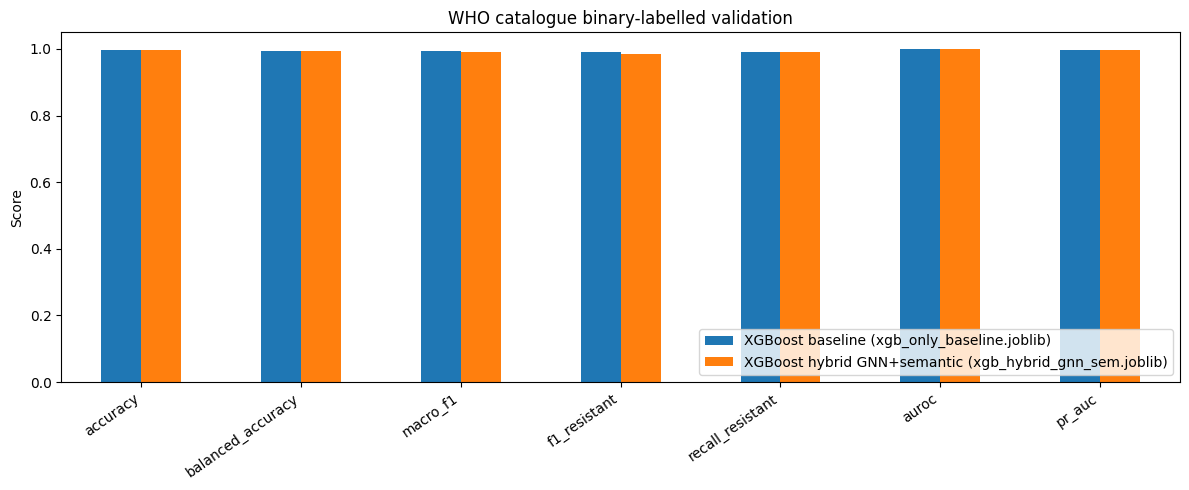

C:\Users\FAHIMA~1\AppData\Local\Temp\ipykernel_23020\3291524980.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


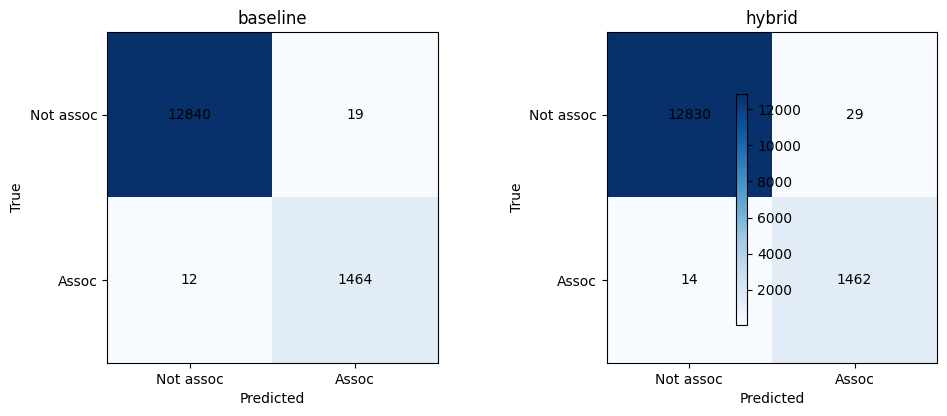

In [13]:
import matplotlib.pyplot as plt

plot_metrics = ["accuracy", "balanced_accuracy", "macro_f1", "f1_resistant", "recall_resistant", "auroc", "pr_auc"]
plot_df = metrics_df.set_index("model")[plot_metrics].T

ax = plot_df.plot(kind="bar", figsize=(12, 5), ylim=(0, 1.05))
ax.set_ylabel("Score")
ax.set_title("WHO catalogue binary-labelled validation")
ax.legend(loc="lower right")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model_key in zip(axes, ["baseline", "hybrid"]):
    cm = confusion_matrix(predictions["true_label"], predictions[f"{model_key}_pred"], labels=[0, 1])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(model_key)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1], ["Not assoc", "Assoc"])
    ax.set_yticks([0, 1], ["Not assoc", "Assoc"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()
plt.show()


In [14]:
n_total = len(who_df)
n_binary = len(who_labelled)
n_uncertain = len(who_unlabelled)
label_counts = who_labelled["true_label"].value_counts().sort_index()

best_row = ranking.iloc[0]
runner_up = ranking.iloc[1]

draft_text = f'''
Draft narasi untuk revisi jurnal:

Validasi biologis diperluas dari 8 kasus literatur menjadi {n_binary:,} entri katalog WHO edisi kedua yang memiliki label biner jelas dari total {n_total:,} entri WHO. Sebanyak {n_uncertain:,} entri dengan confidence uncertain/missing tidak digunakan sebagai ground truth biner. Subset validasi terdiri dari {int(label_counts.get(0, 0)):,} mutasi not associated with resistance dan {int(label_counts.get(1, 0)):,} mutasi associated with resistance. Pada evaluasi pasangan model dengan feature representation 448 dimensi yang sama, model terbaik berdasarkan urutan macro-F1, F1 resisten, recall resisten, PR-AUC, dan AUROC adalah {best_row['model']} dengan macro-F1={best_row['macro_f1']:.4f}, F1 resisten={best_row['f1_resistant']:.4f}, recall resisten={best_row['recall_resistant']:.4f}, AUROC={best_row['auroc']:.4f}, dan PR-AUC={best_row['pr_auc']:.4f}. Model pembanding memperoleh macro-F1={runner_up['macro_f1']:.4f}, F1 resisten={runner_up['f1_resistant']:.4f}, recall resisten={runner_up['recall_resistant']:.4f}, AUROC={runner_up['auroc']:.4f}, dan PR-AUC={runner_up['pr_auc']:.4f}.

Catatan interpretasi: karena dataset training awal juga berasal dari katalog WHO, hasil ini sebaiknya ditulis sebagai validasi konsistensi biologis terhadap katalog WHO, bukan sebagai validasi eksternal independen.
'''
print(draft_text)



Draft narasi untuk revisi jurnal:

Validasi biologis diperluas dari 8 kasus literatur menjadi 14,335 entri katalog WHO edisi kedua yang memiliki label biner jelas dari total 48,332 entri WHO. Sebanyak 33,997 entri dengan confidence uncertain/missing tidak digunakan sebagai ground truth biner. Subset validasi terdiri dari 12,859 mutasi not associated with resistance dan 1,476 mutasi associated with resistance. Pada evaluasi pasangan model dengan feature representation 448 dimensi yang sama, model terbaik berdasarkan urutan macro-F1, F1 resisten, recall resisten, PR-AUC, dan AUROC adalah XGBoost baseline (xgb_only_baseline.joblib) dengan macro-F1=0.9942, F1 resisten=0.9895, recall resisten=0.9919, AUROC=0.9997, dan PR-AUC=0.9981. Model pembanding memperoleh macro-F1=0.9919, F1 resisten=0.9855, recall resisten=0.9905, AUROC=0.9998, dan PR-AUC=0.9984.

Catatan interpretasi: karena dataset training awal juga berasal dari katalog WHO, hasil ini sebaiknya ditulis sebagai validasi konsistensi